# Single-network, single-knob seizure model — NEURON

A single-compartment **HH + A-current (`kA`) + dynamic [K+]o (`kdyn`)** clustered
network with AMPA+NMDA synapses and two-timescale spike-frequency adaptation.

**One fixed network. Normal vs seizure differ by a SINGLE parameter:**
`sahp_ainc_slow` — the slow-AHP / M-current (Kv7/KCNQ) strength.

| state | `sahp_ainc_slow` | phenotype |
|---|---|---|
| **normal**  | 0.009 (strong adaptation) | quiet, sparse loose bursts (~0.2 Hz), [K+]o ~4 mM |
| **seizure** | 0.003 (weak adaptation)   | active loose bursts (~0.7 Hz, ≥35% participation), [K+]o ~4 mM |

Both states use `states.normal_state()` (so `tau_k` stays 200) — this is an
**adaptation-deficit (KCNQ/Kv7) seizure**, the mild-[K+]o bursting phenotype, *not*
the K+-clearance (`tau_k`) ictal route. Raising `sahp_ainc_slow` models a Kv7
opener (retigabine); lowering it models KCNQ2/3 loss-of-function.

This notebook: build one network → normal vs seizure rasters + loose-burst check
→ sweep the single knob → generate two datasets from the SAME wiring → run CCG +
learned-LIF inference on both, reporting connectivity AUC/FDR incl. inhibitory-edge AUC.

> **Prerequisite:** compile the mechanisms once (`cd neuron_simulation && nrnivmodl mechanisms`).

In [1]:
%matplotlib inline

In [2]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath('..')
for p in (REPO_ROOT, os.path.join(REPO_ROOT, 'inference')):
    if p not in sys.path:
        sys.path.insert(0, p)

from neuron_simulation import (
    topology, build_network, run_simulation, states, analysis, plotting, workflows,
)

# ==========================================================================
# SINGLE-NETWORK, SINGLE-KNOB seizure model.
# ONE fixed network (seed 1). Normal vs seizure differ by a SINGLE parameter:
#   sahp_ainc_slow (slow-AHP / M-current strength).
#     NORMAL  = 0.009  strong adaptation  -> quiet, sparse loose bursts
#     SEIZURE = 0.003  weak adaptation    -> active loose bursts
# Both states use states.normal_state() (tau_k stays 200); adaptation-deficit
# (KCNQ/Kv7) seizure, NOT the K+-clearance (tau_k) route.
# ==========================================================================
SAHP_NORMAL, SAHP_SEIZURE = 0.009, 0.003   # the ONLY thing that differs between states

CONFIG = {
    'topology': dict(
        # ---- network size (seed=1 -> N is ~236 cells) ----
        num_clusters=10,                      # number of spatial clusters
        neurons_per_cluster_range=(4, 40),    # (min,max) neurons per cluster
        inhibitory_probability=0.2,           # fraction of neurons that are inhibitory
        seed=1,                               # topology RNG seed (change -> different wiring AND N)

        # ---- spatial layout + distance kernel ----
        space_size=15.0,                      # side length of the square sheet
        cluster_radius=1.0,                   # scatter of neurons around each cluster center
        decay_sigma=3.0,                      # P(connect) *= exp(-d^2 / (2*sigma^2)); LOWER = tighter/more local
        max_connection_distance=8.0,          # hard cutoff: no edges beyond this distance

        # ============ CONNECTION PROBABILITY  (<-- tune these) ============
        #   cell_type_specific=False -> type-blind, 2 knobs (within/between).  <-- reproduces the figures
        #   cell_type_specific=True  -> per-type, 6 knobs (p_*); within/between are IGNORED.
        # In BOTH modes the base prob is then multiplied by the distance kernel
        # above and by each PREsynaptic cell's log-normal propensity (ln_sigma).
        # =================================================================
        cell_type_specific=False,
        # -- simple mode (LIVE when cell_type_specific=False) --
        within_cluster_prob=0.25,             # P(edge) for a same-cluster pair
        between_cluster_prob=0.06,            # P(edge) for an across-cluster pair
        # -- per-type mode (LIVE only when cell_type_specific=True); inhibition is LOCAL (no between) --
        p_ee_within=0.15, p_ee_between=0.02,  # exc -> exc  (within / between clusters)
        p_ei_within=0.30, p_ei_between=0.01,  # exc -> inh
        p_ie_within=0.70,                     # inh -> exc  (between forced to 0)
        p_ii_within=0.50,                     # inh -> inh  (between forced to 0)

        # ---- degree distribution / density ----
        ln_sigma=0.5,                         # per-neuron log-normal propensity spread; HIGHER = heavier hub tail
        target_density=None,                  # None -> density falls out of the probs; e.g. 0.03 rescales to it
    ),
    'build': dict(
        synapse_model='ampa_nmda', exc_tau=5.0, tau_nmda=350.0, nmda_ratio=3.0,
        exc_weight_scale=3.0, inh_weight_scale=2.5, depression_d=0.2, tau_d=500.0,
        noise_rate=18.0, noise_weight=0.004, adapt=True,
        sahp_ainc_fast=0.005, sahp_tau_fast=300.0,
        sahp_ainc_slow=SAHP_NORMAL, sahp_tau_slow=6500.0, delay_per_distance=2.0,
    ),
    'sim': dict(dt=0.05, discard_transient_ms=1000.0),
}

def build_for(sahp_slow):
    """build_kwargs for one state: identical network, only sahp_ainc_slow differs."""
    b = dict(CONFIG['build']); b['sahp_ainc_slow'] = sahp_slow; return b

def loose_bursts(res, duration_ms, thresh=0.35):
    """Loose (low-participation) burst detector: the default >80% detector misses
    these events, so use >=35% participation."""
    b = analysis.detect_network_bursts(res['spike_data'], N, duration_ms,
                                       participation_threshold=thresh, burn_in_ms=0.0)
    return b, analysis.burst_statistics(b, duration_ms, burn_in_ms=0.0)

print('config ready (single-knob: SAHP_NORMAL=%.3f, SAHP_SEIZURE=%.3f)' % (SAHP_NORMAL, SAHP_SEIZURE))

config ready (single-knob: SAHP_NORMAL=0.009, SAHP_SEIZURE=0.003)


## 1. Build the topology (log-normal — preferred)

Continuous heavy-tailed degree distribution (no bimodal gap) at ~3–4% density.
Use `topology.build_topology(...)` for the discrete-hub variant.

**Tuning connection probability.** The wiring is set by `CONFIG['topology']` in the config cell above. Two modes:

- **`cell_type_specific=False`** (default; used for the rasters below) -- one within-cluster and one between-cluster probability: `within_cluster_prob=0.25`, `between_cluster_prob=0.06`.
- **`cell_type_specific=True`** -- six per-type probabilities `p_ee_within/between`, `p_ei_within/between`, `p_ie_within`, `p_ii_within` (inhibition is local, so there are no between-cluster inhibitory edges). In this mode `within/between_cluster_prob` are ignored.

In either mode the base probability is scaled by the distance kernel (`decay_sigma`, `max_connection_distance`) and by each presynaptic cell's log-normal propensity (`ln_sigma`); set `target_density` to rescale the whole network to a fixed density. Edit the values, re-run the cell below, and the printed connection stats + 4-panel report update. Changing `seed` or `num_clusters` changes the neuron count `N`.

Topology 'lognormal': 236 neurons, 2000 synapses, density=3.61%
==== TOPOLOGY STATS ====
N = 236 neurons | 2000 directed synapses | 10 clusters (sizes 7/23/40)
OVERALL density        = 3.61%
WITHIN-cluster rate    = 23.64%
BETWEEN-cluster rate   = 0.920%
WITHIN : BETWEEN ratio = 25.7 x
edge composition       = 78% within, 22% between
out-degree mean/median/max = 8.5/7/50
hubs (top 10% out-deg, >= 15) = 30 cells carry 30% of all outgoing edges


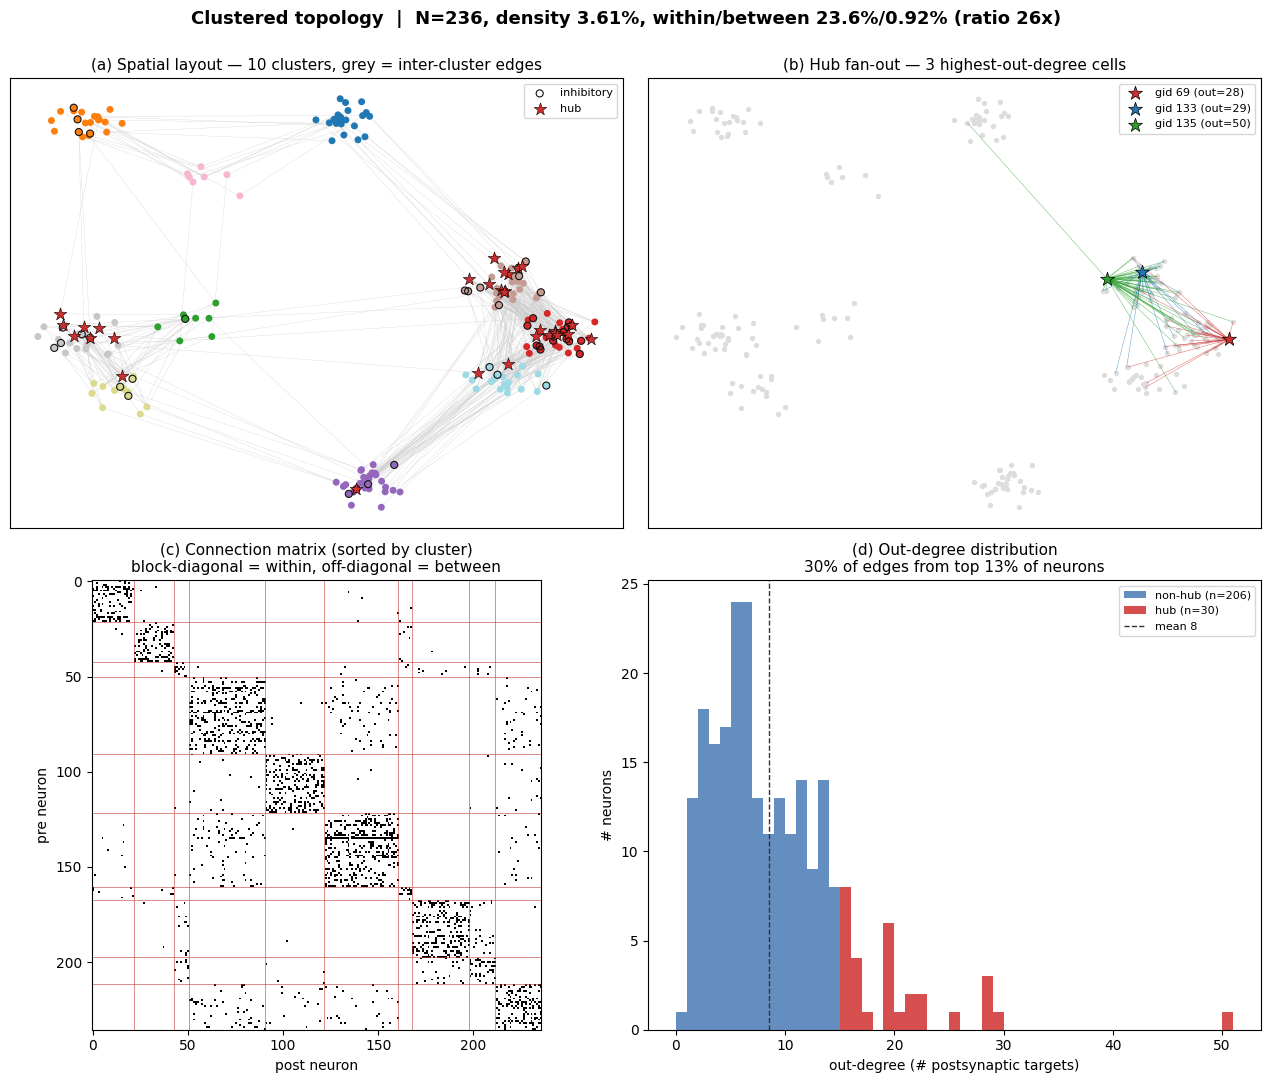

In [3]:
topo = topology.build_topology_lognormal(**CONFIG['topology'])
N = topo['n_neurons']

# One-call topology view: prints the inter/between-cluster connection stats
# (density, within/between rates, ratio, hub share) and returns the 4-panel
# overview (spatial layout, hub fan-out, cluster-sorted connection matrix,
# out-degree distribution). Supersedes the separate map + degree plots.
stats, fig = plotting.topology_report(topo)
plt.show()

## 2. Normal state — strong adaptation (`sahp_ainc_slow = 0.009`)

Quiet, sparse **loose** bursts (~0.2 Hz) with a low-firing async baseline; [K+]o ~4 mM.
Loose bursts are low-participation, so we detect them at **≥35% participation**
(the default >80% detector misses them). Both rasters are shown; genuine
network-wide synchrony survives the row shuffle.

Built network: 236 cells, 2000 synapses, celsius=6.3, gbar_kA(exc)=0.006, depression_d=0.2
Ran 61000 ms (kept 60000 ms), 4750 spikes, mean rate 0.34 Hz, [K+]o 4.0-4.1 mM
[normal] 0 network bursts (0.00 Hz), mean participation nan, [K+]o 4.0-4.1 mM
NORMAL  sahp_ainc_slow=0.009
  loose bursts: 6 (0.10 Hz) | participation 0.42 | firing 0.34 Hz | [K+]o 4.0-4.1 mM


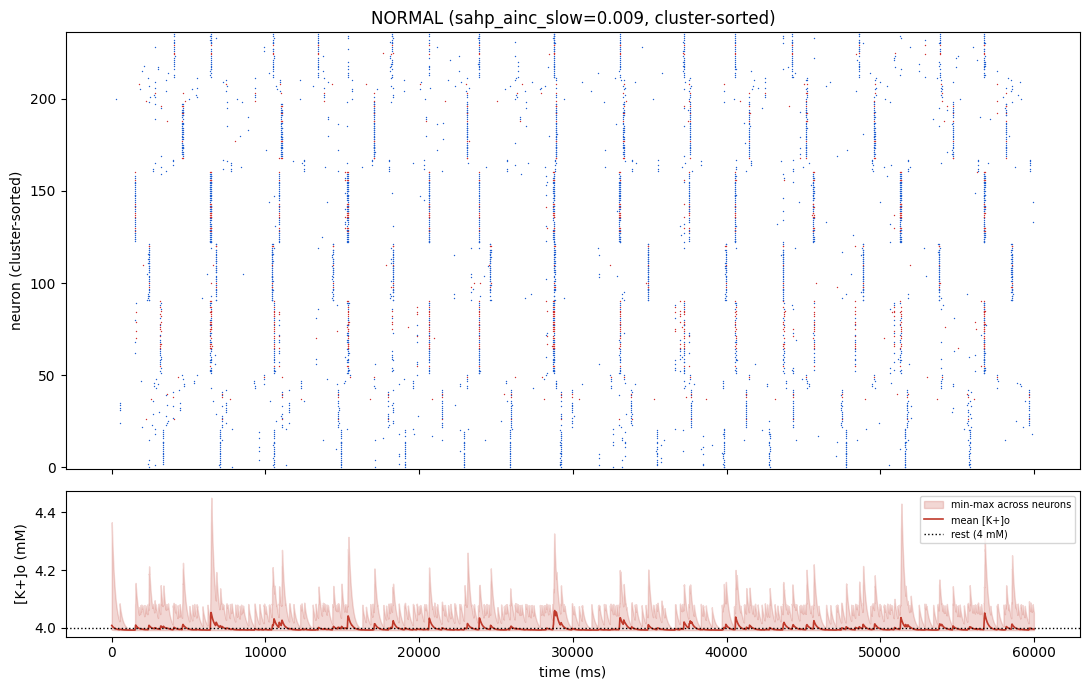

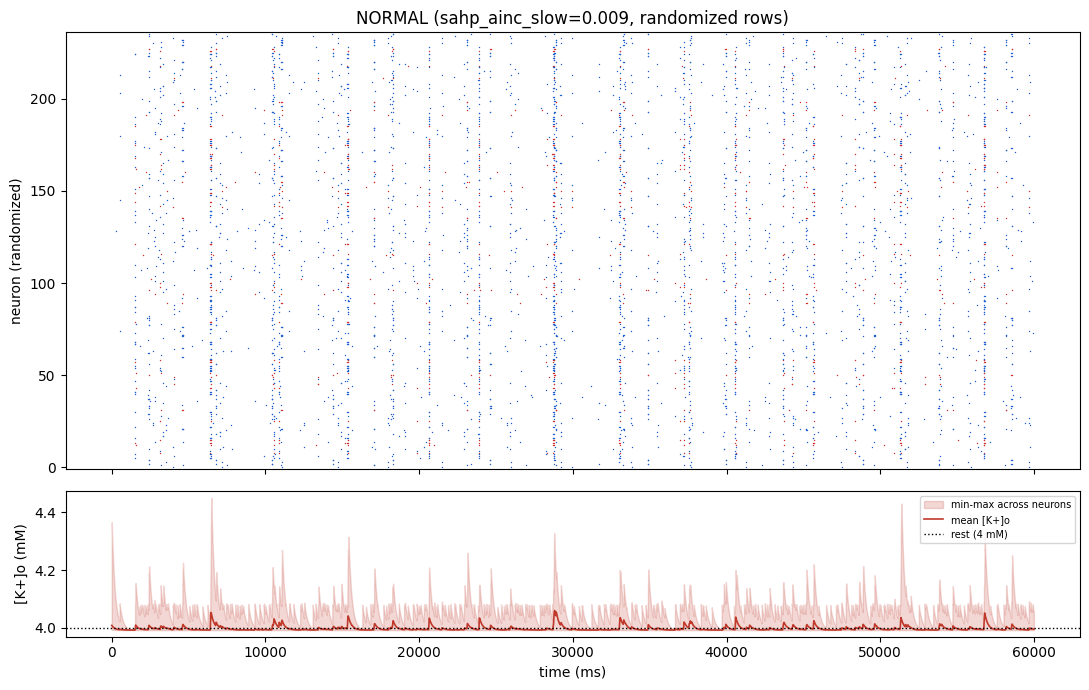

In [4]:
DUR = 60000.0   # 60 s -> captures several multi-second inter-burst intervals
normal = workflows.run_single_state(
    topo, state=states.normal_state(), build_kwargs=build_for(SAHP_NORMAL),
    duration=DUR, record_ko=True, **CONFIG['sim'])
_, nstats = loose_bursts(normal, DUR)          # loose (>=35%) burst detector
nrate = analysis.firing_rate_summary(normal['spike_data'], DUR, burn_in_ms=0.0)['mean_rate_hz']
print('NORMAL  sahp_ainc_slow=%.3f' % SAHP_NORMAL)
print('  loose bursts: %d (%.2f Hz) | participation %.2f | firing %.2f Hz | [K+]o %.1f-%.1f mM' % (
    nstats['n_bursts'], nstats['burst_rate_hz'], nstats['mean_participation'], nrate,
    float(normal['ko_data']['mean_ko'].min()), float(normal['ko_data']['mean_ko'].max())))

for rr, tag in [(False, 'cluster-sorted'), (True, 'randomized rows')]:
    fig = plotting.plot_raster_with_ko(
        normal['spike_data'], N, DUR, normal['ko_data'],
        is_inhibitory=topo['neuron_is_inhibitory'],
        cluster_assignments=topo['cluster_assignments'],
        title='NORMAL (sahp_ainc_slow=%.3f, %s)' % (SAHP_NORMAL, tag), randomize_rows=rr)
    plt.show()

## 3. Seizure state — weak adaptation (`sahp_ainc_slow = 0.003`)

The **same wired network**, only the slow-AHP knob lowered. Active loose bursts
(~0.7 Hz, ≥35% participation); [K+]o still ~4 mM (adaptation-deficit, not a
K+-clearance ictal event).

Built network: 236 cells, 2000 synapses, celsius=6.3, gbar_kA(exc)=0.006, depression_d=0.2
Ran 61000 ms (kept 60000 ms), 14411 spikes, mean rate 1.02 Hz, [K+]o 4.0-4.3 mM
[normal] 0 network bursts (0.00 Hz), mean participation nan, [K+]o 4.0-4.3 mM
SEIZURE sahp_ainc_slow=0.003
  loose bursts: 16 (0.27 Hz) | participation 0.52 | firing 1.02 Hz | [K+]o 4.0-4.3 mM
OK: lowering sahp_ainc_slow (0.009 -> 0.003) turns quiet -> active bursting on the SAME network


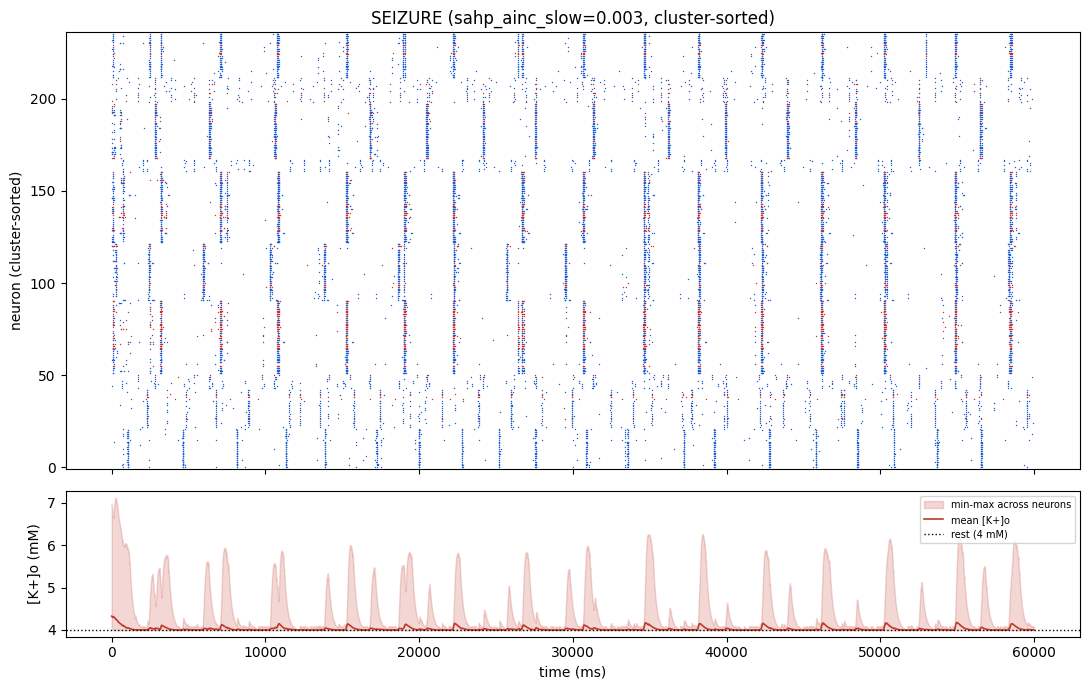

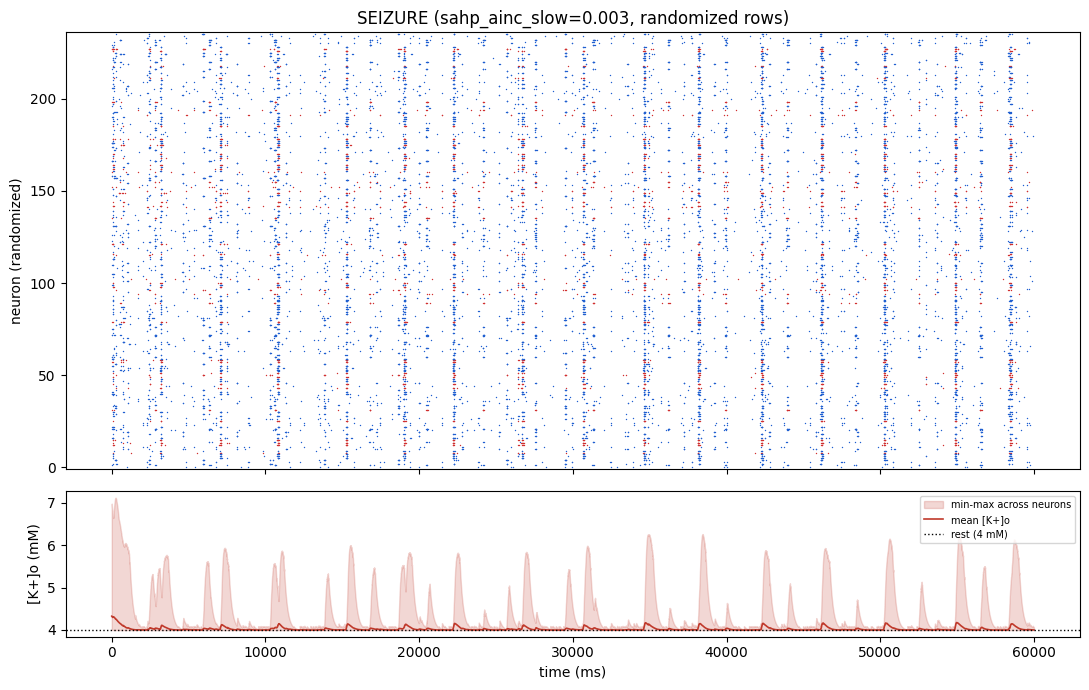

In [5]:
seizure = workflows.run_single_state(
    topo, state=states.normal_state(), build_kwargs=build_for(SAHP_SEIZURE),
    duration=DUR, record_ko=True, **CONFIG['sim'])
_, sstats = loose_bursts(seizure, DUR)
srate = analysis.firing_rate_summary(seizure['spike_data'], DUR, burn_in_ms=0.0)['mean_rate_hz']
print('SEIZURE sahp_ainc_slow=%.3f' % SAHP_SEIZURE)
print('  loose bursts: %d (%.2f Hz) | participation %.2f | firing %.2f Hz | [K+]o %.1f-%.1f mM' % (
    sstats['n_bursts'], sstats['burst_rate_hz'], sstats['mean_participation'], srate,
    float(seizure['ko_data']['mean_ko'].min()), float(seizure['ko_data']['mean_ko'].max())))
assert sstats['burst_rate_hz'] > nstats['burst_rate_hz'], 'seizure should burst more than normal'
assert sstats['mean_participation'] >= 0.35, 'seizure loose bursts should reach >=35% participation'
print('OK: lowering sahp_ainc_slow (0.009 -> 0.003) turns quiet -> active bursting on the SAME network')

for rr, tag in [(False, 'cluster-sorted'), (True, 'randomized rows')]:
    fig = plotting.plot_raster_with_ko(
        seizure['spike_data'], N, DUR, seizure['ko_data'],
        is_inhibitory=topo['neuron_is_inhibitory'],
        cluster_assignments=topo['cluster_assignments'],
        title='SEIZURE (sahp_ainc_slow=%.3f, %s)' % (SAHP_SEIZURE, tag), randomize_rows=rr)
    plt.show()

## 4. The single knob — `sahp_ainc_slow` sweep

`sahp_ainc_slow` is the whole story: sweeping it 0.003 → 0.009 gives a graded
transition from active bursting (KCNQ loss) to quiet (Kv7-opener / retigabine).

Built network: 236 cells, 2000 synapses, celsius=6.3, gbar_kA(exc)=0.006, depression_d=0.2
Ran 31000 ms (kept 30000 ms), 7216 spikes, mean rate 1.02 Hz, [K+]o 4.0-4.3 mM
[normal] 0 network bursts (0.00 Hz), mean participation nan, [K+]o 4.0-4.3 mM
sahp_ainc_slow=0.003 -> loose-burst rate 0.27 Hz, participation 0.47
Built network: 236 cells, 2000 synapses, celsius=6.3, gbar_kA(exc)=0.006, depression_d=0.2
Ran 31000 ms (kept 30000 ms), 5595 spikes, mean rate 0.79 Hz, [K+]o 4.0-4.2 mM
[normal] 0 network bursts (0.00 Hz), mean participation nan, [K+]o 4.0-4.2 mM
sahp_ainc_slow=0.004 -> loose-burst rate 0.27 Hz, participation 0.48
Built network: 236 cells, 2000 synapses, celsius=6.3, gbar_kA(exc)=0.006, depression_d=0.2
Ran 31000 ms (kept 30000 ms), 4504 spikes, mean rate 0.64 Hz, [K+]o 4.0-4.1 mM
[normal] 0 network bursts (0.00 Hz), mean participation nan, [K+]o 4.0-4.1 mM
sahp_ainc_slow=0.005 -> loose-burst rate 0.23 Hz, participation 0.46
Built network: 236 cells, 2000 synapses, celsius=

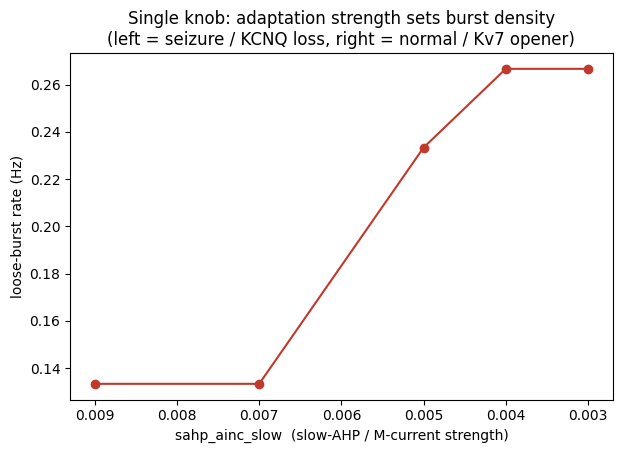

In [6]:
# Graded transition: sweep the ONLY knob (seizure 0.003 -> normal 0.009).
sweep_vals = [0.003, 0.004, 0.005, 0.007, 0.009]
SWDUR = 30000.0
rates, parts = [], []
for v in sweep_vals:
    r = workflows.run_single_state(topo, state=states.normal_state(),
                                   build_kwargs=build_for(v), duration=SWDUR, record_ko=True, **CONFIG['sim'])
    _, st = loose_bursts(r, SWDUR)
    rates.append(st['burst_rate_hz']); parts.append(st['mean_participation'])
    print('sahp_ainc_slow=%.3f -> loose-burst rate %.2f Hz, participation %.2f' % (v, st['burst_rate_hz'], st['mean_participation']))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep_vals, rates, 'o-', color='#c0392b')
ax.set_xlabel('sahp_ainc_slow  (slow-AHP / M-current strength)')
ax.set_ylabel('loose-burst rate (Hz)')
ax.set_title('Single knob: adaptation strength sets burst density\n(left = seizure / KCNQ loss, right = normal / Kv7 opener)')
ax.invert_xaxis()   # seizure (low sahp) on the left
plt.show()

## 5. Two datasets from the SAME network (normal vs seizure knob)

Both datasets use `states.normal_state()` and the **same** `seed=1` topology, so
the ground-truth wiring is identical; they differ ONLY by `sahp_ainc_slow`. This
is the slow cell (2 × 10 × 60 s). Saved to `NEURON data/normal` and `NEURON data/seizure`.

In [7]:
# Two datasets from the SAME wired network (seed 1 -> identical ground truth);
# they differ ONLY by sahp_ainc_slow, so inference sees the same graph under two
# activity regimes: sparse-async (normal) vs burst-dense (seizure).
meta_n, dir_n = workflows.generate_dataset(
    n_recordings=15, recording_duration=60000.0,
    topology_kind='lognormal', topology_kwargs=CONFIG['topology'],
    build_kwargs=build_for(SAHP_NORMAL), state=states.normal_state(),
    record_voltage=True, save_dir='NEURON data/normal', **CONFIG['sim'])
print('normal dataset  ->', dir_n)

meta_s, dir_s = workflows.generate_dataset(
    n_recordings=15, recording_duration=60000.0,
    topology_kind='lognormal', topology_kwargs=CONFIG['topology'],
    build_kwargs=build_for(SAHP_SEIZURE), state=states.normal_state(),
    record_voltage=True, save_dir='NEURON data/seizure', **CONFIG['sim'])
print('seizure dataset ->', dir_s)
print('normal  per-rec spikes:', [r['num_spikes'] for r in meta_n['recordings']])
print('seizure per-rec spikes:', [r['num_spikes'] for r in meta_s['recordings']])

NEURON SESSION 20260711_040614  (lognormal, state=normal)
Topology 'lognormal': 236 neurons, 2000 synapses, density=3.61%
Built network: 236 cells, 2000 synapses, celsius=6.3, gbar_kA(exc)=0.006, depression_d=0.2
Network structure saved to: NEURON data/normal\20260711_040614\network_20260711_040614.npz
==== TOPOLOGY STATS ====
N = 236 neurons | 2000 directed synapses | 10 clusters (sizes 7/23/40)
OVERALL density        = 3.61%
WITHIN-cluster rate    = 23.64%
BETWEEN-cluster rate   = 0.920%
WITHIN : BETWEEN ratio = 25.7 x
edge composition       = 78% within, 22% between
out-degree mean/median/max = 8.5/7/50
hubs (top 10% out-deg, >= 15) = 30 cells carry 30% of all outgoing edges
  topology figure -> NEURON data/normal\20260711_040614\topology_20260711_040614.png

--- recording 1/15 ---
Ran 61000 ms (kept 60000 ms), 4750 spikes, mean rate 0.34 Hz
  0 bursts (0.00 Hz), mean participation nan
Recording 0 saved to: NEURON data/normal\20260711_040614\recording000.npz (236 neurons, 600 resamp

## 6. Inference on both datasets (same wiring, two regimes)

CCG baseline + learned-LIF on each session. `adapter.run_inference` reports the
overall connectivity **AUC/FDR** and the **inhibitory-edge AUC** (positive class
I→E, I→I; baseline to beat ~0.475). Same ground truth, so any difference is the
activity regime (burst-dense seizure vs sparse-async normal).

In [8]:
import adapter  # inference/adapter.py

def score(tag, session_dir):
    print('\n========== %s ==========' % tag)
    adapter.validate_session_format(session_dir)
    s = adapter.run_inference(session_dir, run_learned=True, run_ccg=True,
                              learned_params={'n_epochs': 20, 'K': 60})
    L = s.get('learned') or {}
    print('%s learned: AUC=%s FDR=%.3f | inhibitory-edge AUC=%s | excitatory-edge AUC=%s' % (
        tag, L.get('auc'), L.get('fdr', float('nan')), L.get('auc_inhibitory'), L.get('auc_excitatory')))
    return s

summ_n = score('NORMAL', dir_n)
summ_s = score('SEIZURE', dir_s)

print('\n=== SUMMARY (identical wiring, two regimes) ===')
for tag, s in [('normal', summ_n), ('seizure', summ_s)]:
    L = s.get('learned') or {}; C = s.get('ccg') or {}
    print('%-8s learned AUC %s (inh %s / exc %s) | CCG AUC %s' % (
        tag, L.get('auc'), L.get('auc_inhibitory'), L.get('auc_excitatory'), C.get('auc')))


========== NORMAL ==========
[validate] OK: N=236, connections=2000, duration=60000 ms, voltage=yes
[validate] OK: N=236, connections=2000, duration=60000 ms, voltage=yes

=== learned-LIF (spike-only) ===

LEARNED LIF CONNECTIVITY (Event Windows + Per-Neuron Weights)
Session: 20260711_040614
K=60, epochs=20, lr=0.001, max_delay=5, l1=0.01
Window: warmup=30, pre=50, post=10 (90 bins)
Event anchor mode: post
Threshold mode: adaptive
Connectivity thresholding: oracle_f1
Device: cuda

  Loading data...
  Loaded 15 recordings, total duration: 900s
  Neurons: 236, Connections: 2000
  Spike matrix: [236, 900000] (71512 total spikes)
  Recording boundaries: [0, 60000, 120000, 180000, 240000, 300000, 360000, 420000, 480000, 540000, 600000, 660000, 720000, 780000, 840000, 900000]
  Detected burst windows: 130
  Detected excluded bins: 75250
  Mean burst threshold: 0.159 active fraction per 100 ms bin
  Total excluded bins: 75250
  Candidate mode: hybrid
  Candidate mix: 48 spatial + 12 temporal

## 7. GLM connectivity — lag-1 readout, label-free operating point

Multivariate GLM scored by the **lag-1** coefficient (the sharp ~5 ms
monosynaptic window) rather than the summed 1..max_lag window. The operating
point is **label-free**: the threshold is set by a spike-jitter null at a target
FDR (no ground truth). Neuron E/I type is inferred from the sign of net outgoing
weight, and inhibitory edges are scored only among inferred-inhibitory
presynaptic neurons. Reports exc/inh AUC + AP, neuron-type AUC, and the
recovered-wiring confusion at the FDR-controlled threshold, plus a table vs
CCG / learned-LIF. (Runs on spikes alone — works on the *existing* sessions
without re-running cell 11.)

In [ ]:
from lif_inference import glm_connectivity as glm
import glob as _glob, os as _os

# Use the sessions from cell 11 if it ran this session; otherwise fall back to
# the newest session already on disk (so you can run the GLM without the ~24 h
# regeneration). GLM needs only the recording*.npz spike files.
def _latest(state):
    ds = sorted(d for d in _glob.glob(_os.path.join('NEURON data', state, '*')) if _os.path.isdir(d))
    return ds[-1] if ds else None
dir_n = globals().get('dir_n') or _latest('normal')
dir_s = globals().get('dir_s') or _latest('seizure')
print('normal ->', dir_n, '\nseizure->', dir_s)

def glm_report(tag, session_dir):
    result, m = glm.run(session_dir)   # lag-1 readout + label-free jitter-FDR threshold
    ca = m['confusion_all_edges']
    print('%-7s GLM(lag1): exc AUC=%.3f AP=%.3f | inh AUC=%.3f AP=%.3f | neuron-type AUC=%.3f' % (
        tag, m['auc_excitatory'], m['ap_excitatory'], m['auc_inhibitory'], m['ap_inhibitory'],
        m.get('auc_neuron_type', float('nan'))))
    print('         label-free @FDR %.2f: %d exc + %d inh predicted -> wiring TP=%d/%d FP=%d FN=%d (P=%.2f R=%.2f F1=%.2f)' % (
        result['target_fdr'], result['n_pred_exc'], result['n_pred_inh'],
        ca['TP'], m['n_true_edges'], ca['FP'], ca['FN'], ca['precision'], ca['recall'], ca['f1']))
    return result, m

res_n, m_n = glm_report('normal', dir_n)
res_s, m_s = glm_report('seizure', dir_s)

# combined candidate-set AUC table vs CCG / learned-LIF (from cell 13's summ_* if adapter ran)
print('\n=== candidate-set AUC by method ===')
for tag, mm, s in [('normal', m_n, globals().get('summ_n')),
                   ('seizure', m_s, globals().get('summ_s'))]:
    ccg = (s.get('ccg') or {}).get('auc') if s else None
    lrn = (s.get('learned') or {}).get('auc') if s else None
    print('%-8s | GLM exc %.3f / inh %.3f | CCG %s | learned %s' % (
        tag, mm['auc_excitatory'], mm['auc_inhibitory'],
        ('%.3f' % ccg) if ccg is not None else '  -  ',
        ('%.3f' % lrn) if lrn is not None else '  -  '))

## 8. Lag-1 vs summed-window readout

The key change is scoring by the **lag-1** coefficient instead of the summed
1..max_lag window (which blurs the sharp monosynaptic signal with polysynaptic /
common-input lags). Same data, both readouts — AUC/AP and neuron-type recovery.
(Fast: just two ridge fits, no jitter surrogates.)

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

_s = glm.load_spikes(dir_n)
_gt = glm.load_ground_truth(dir_n)
_M, _bnd = glm.build_spike_matrix(_s['recordings'], _s['n_neurons'], 5.0)
_cand, _ = glm.candidate_mask(_s['n_neurons'])

print('readout | exc AUC / AP  | inh AUC / AP  | neuron-type AUC')
for ro in ['lag1', 'sum']:
    _W = glm.glm_connectivity(_M, _bnd, readout=ro)
    ye, se = _gt['A_exc'][_cand], _W[_cand]
    yi, si = _gt['A_inh'][_cand], -_W[_cand]
    print('%-7s | %.3f / %.3f | %.3f / %.3f | %.3f' % (
        ro, roc_auc_score(ye, se), average_precision_score(ye, se),
        roc_auc_score(yi, si), average_precision_score(yi, si),
        roc_auc_score(_gt['is_inhibitory'], -_W.sum(1))))
print('\nlag-1 sharpens the ~5 ms monosynaptic coefficient; sum averages it with lags 2..max_lag.')

## 9. Predicted topology colored by correctness (TP / FP / FN)

The **label-free** predicted adjacency (`result['pred_adjacency']`) against the
ground-truth wiring: **TP** (green) = correctly recovered edges, **FP** (red) =
false alarms, **FN** (orange, dotted) = missed true edges. Left = spatial layout
(inhibitory neurons outlined); right = cluster-sorted adjacency. TP concentrate
*within* clusters (dense recurrence the GLM resolves); FN are mostly the weaker
*between-cluster* edges. Uses `res_n`/`res_s` from §7 — run §7 first.

In [ ]:
import glob as _glob, os as _os
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

def plot_glm_topology(tag, session_dir, result):
    gt = glm.load_ground_truth(session_dir)
    if gt is None:
        print('no network_*.npz in', session_dir, '- cannot score against truth'); return
    net = np.load(sorted(_glob.glob(_os.path.join(session_dir, 'network_*.npz')))[0], allow_pickle=True)
    pos = np.asarray(net['neuron_positions'], float)
    ca = np.asarray(net['cluster_assignments']).astype(int)
    inh_true = np.asarray(net['neuron_is_inhibitory']).astype(bool)
    N = len(pos); off = ~np.eye(N, dtype=bool)
    A_edge = (gt['A_exc'] | gt['A_inh']) & off
    pred, cand = result['pred_adjacency'], result['candidates']
    tp = pred & A_edge
    fp = pred & ~A_edge & cand
    fn = A_edge & ~pred
    TP, FP, FN = int(tp.sum()), int(fp.sum()), int(fn.sum())
    Pr = TP/(TP+FP) if TP+FP else 0.0
    Rc = TP/(TP+FN) if TP+FN else 0.0
    F1 = 2*Pr*Rc/(Pr+Rc) if Pr+Rc else 0.0
    segs = lambda m: [[pos[i], pos[j]] for i, j in np.argwhere(m)]

    fig, ax = plt.subplots(1, 2, figsize=(16, 7.5))
    a = ax[0]
    a.add_collection(LineCollection(segs(fn), colors='#f0a000', lw=0.3, alpha=0.45, linestyles='dotted'))
    a.add_collection(LineCollection(segs(tp), colors='#1a9850', lw=0.55, alpha=0.85))
    a.add_collection(LineCollection(segs(fp), colors='#d73027', lw=0.55, alpha=0.85))
    a.scatter(pos[~inh_true, 0], pos[~inh_true, 1], s=13, c='#888', zorder=3)
    a.scatter(pos[inh_true, 0], pos[inh_true, 1], s=30, facecolors='none', edgecolors='k', lw=1.0, zorder=4)
    a.legend(handles=[
        Line2D([0], [0], color='#1a9850', lw=2, label='TP (%d correct)' % TP),
        Line2D([0], [0], color='#d73027', lw=2, label='FP (%d false)' % FP),
        Line2D([0], [0], color='#f0a000', lw=2, ls=':', label='FN (%d missed)' % FN),
        Line2D([0], [0], marker='o', color='none', markerfacecolor='none', markeredgecolor='k', label='inhibitory'),
    ], fontsize=10, loc='upper right')
    a.set_title('%s - GLM-predicted topology, label-free  (P=%.2f R=%.2f F1=%.2f)' % (tag, Pr, Rc, F1), fontsize=12)
    a.set_xticks([]); a.set_yticks([])

    order = np.argsort(ca, kind='stable')
    M = np.zeros((N, N)); M[fn] = 1; M[fp] = 2; M[tp] = 3
    b = ax[1]
    b.imshow(M[np.ix_(order, order)], cmap=ListedColormap(['white', '#f0a000', '#d73027', '#1a9850']),
             vmin=0, vmax=3, interpolation='nearest', aspect='equal')
    b.set_title('%s - adjacency (cluster-sorted): TP green, FP red, FN orange' % tag, fontsize=12)
    b.set_xlabel('post'); b.set_ylabel('pre')
    fig.suptitle('%s: GLM v2 (lag-1, label-free) predicted vs true wiring - %d/%d edges recovered'
                 % (tag, TP, int(A_edge.sum())), fontsize=13, weight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

plot_glm_topology('normal', dir_n, res_n)
plot_glm_topology('seizure', dir_s, res_s)

## Notes & caveats

- **The seizure knob here is `sahp_ainc_slow`**, not `tau_k`. Lowering it
  (0.009 → 0.003) reduces slow adaptation (KCNQ2/3 loss-of-function), turning the
  same network from quiet to actively bursting. Both states keep `tau_k=200` and
  use `normal_state()`, so [K+]o stays ~4 mM (mild-[K+]o bursting phenotype).
- For the **K+-clearance ictal mechanism** instead (higher [K+]o ~18 mM), use the
  `seizure_state` / `tau_k` route — but first set the `states.py` `NORMAL_SAHP_*`
  constants to match this base (`NORMAL_SAHP_SLOW=0.009`, `NORMAL_SAHP_FAST=0.005`)
  so it reduces adaptation from the true normal values.
- **Loose bursts** are low-participation events, so the default >80% burst detector
  misses them — this notebook uses `participation_threshold=0.35`.
- The **ground truth is the exact wired graph** (`connections`), identical across
  the normal and seizure datasets (same `seed=1`), so the two inference runs
  isolate the effect of activity regime on an identical network.

## Parameter tuning guide

All knobs below are `build_kwargs` (passed to `build_network`) unless noted. The
defaults already give the realistic regime; change these to move the operating
point. Effects are coupled -- see the trade-offs at the end.

**Network dynamics**

| Want to change | Knob | Direction |
|---|---|---|
| Burst *rate* (slower/faster) | `sahp_ainc_slow`, `sahp_tau_slow` | higher -> slower bursts (longer IBI). Default 0.2 Hz. |
| *Spikes per burst* (thinner) | `sahp_ainc_fast` | higher -> fewer spikes/burst. Default ~2. |
| *Inter-burst background* firing | `noise_weight`, `noise_rate` | higher -> more background (fills gaps) |
| Burst *duration* | `nmda_ratio`, `delay_per_distance` | higher -> longer (reverberation / propagation) |
| Overall excitability | `exc_weight_scale`, `inh_weight_scale` | exc up / inh down -> more excitable |

**Topology** (`topology.build_topology_lognormal(...)` args)

| Want to change | Knob | Notes |
|---|---|---|
| Clustering strength | `within_cluster_prob` | *only works with* `target_density=None` |
| Overall density / in-degree | `target_density` | `None` = emerge from probs; a number = fixed density |
| Network size | `num_clusters`, `neurons_per_cluster_range` | e.g. (4, 40) for heterogeneous clusters |
| Spatial extent | `space_size` | scales the distance-dependent delays |

**Seizure** (`states.py` module constants)

| Want to change | Knob | Direction |
|---|---|---|
| Seizure firing/burst rate | `SEIZURE_SAHP_SLOW`, `SEIZURE_SAHP_FAST` | higher -> calmer (more adaptation retained) |
| Ictal [K+]o level | `SEIZURE_TAU_K` | higher -> more [K+]o accumulation |
| Per-run severity | `states.seizure_state(severity)` | higher severity -> higher `tau_k` -> stronger |

**Coupled trade-offs (can't optimize independently)**

- **Burst rate vs inter-burst firing:** a slower burst rate needs a stronger slow AHP, which also suppresses inter-burst firing. Slower bursts -> sparser background.
- **Spikes/burst vs burst duration:** fewer spikes/cell -> shorter bursts (duration is roughly spikes x intra-burst ISI), unless bursts propagate spatially.
- **Seizure firing vs ictal [K+]o:** firing *drives* [K+]o, so a calmer seizure (bounded firing) also gives a bounded [K+]o (~8 mM). For a higher [K+]o at bounded firing, raise `SEIZURE_TAU_K` / severity rather than cutting adaptation.
- **Uniform vs empty gaps:** uniform background needs strong enough independent noise; below a floor the recurrent network organizes gap firing into sparse mini-bursts.

**Backward compatibility:** the pre-tuning regime is still reachable via `build_network(synapse_model='depsyn', adapt=False, delay_per_distance=0.0, ...)` and `build_topology_lognormal(target_density=0.035, within_cluster_prob=0.55, ...)`.